# 🧠 Introduction to CNNs for Image Classification

Until now, you've learned how to apply machine learning to structured datasets (like predicting prices or classifying data based on features). But how can we teach a machine to recognize images, like telling the difference between a **headlight**, a **bumper**, or a **wheel**?

That’s where **Convolutional Neural Networks (CNNs)** come in. CNNs are the **go-to architecture** in deep learning when it comes to visual understanding.

---

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

print("Current folder:", os.getcwd())
print("Files available:", os.listdir("/content"))

Current folder: /content
Files available: ['.config', 'sample_data']


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['1000239834.jpeg', 'Untitled spreadsheet.gsheet', 'Cap3.zip', 'Colab Notebooks', 'ColabDatasets']


In [ ]:
print(os.listdir("/content/drive/MyDrive/ColabDatasets"))

['dataset.zip']


In [ ]:
import os
import zipfile

zip_path = "/content/drive/MyDrive/ColabDatasets/dataset.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
print(os.listdir("/content"))

['.config', 'dataset', 'drive', 'sample_data']


In [ ]:
print(os.listdir("/content/dataset"))

['.ipynb_checkpoints', 'car parts.csv', 'test', 'valid', 'train']


In [ ]:
print(os.listdir("/content/dataset/train"))

['TAILLIGHTS', 'AIR COMPRESSOR', 'LOWER CONTROL ARM', 'CLUTCH PLATE', 'THERMOSTAT', 'STARTER', 'VACUUM BRAKE BOOSTER', 'RADIO', 'SHIFT KNOB', 'VALVE LIFTER', 'RADIATOR', 'MUFFLER', 'OIL PAN', 'RADIATOR FAN', 'SPARK PLUG', 'PRESSURE PLATE', 'IGNITION COIL', 'HEADLIGHTS', 'BRAKE PAD', 'INSTRUMENT CLUSTER', 'ALTERNATOR', 'PISTON', 'DISTRIBUTOR', 'OIL FILTER', 'LEAF SPRING', 'OXYGEN SENSOR', 'GAS CAP', 'ENGINE VALVE', 'CRANKSHAFT', 'OIL PRESSURE SENSOR', 'SPOILER', 'BRAKE CALIPER', 'OVERFLOW TANK', 'BRAKE ROTOR', 'CAMSHAFT', 'CYLINDER HEAD', 'WATER PUMP', 'FUSE BOX', 'RIM', 'COIL SPRING', 'FUEL INJECTOR', 'SIDE MIRROR', 'ENGINE BLOCK', 'IDLER ARM', 'RADIATOR HOSE', 'BATTERY', 'TORQUE CONVERTER', 'WINDOW REGULATOR', 'TRANSMISSION', 'CARBERATOR']


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    level = root.replace("/content", "").count(os.sep)

    if level <= 3:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")

        for folder in dirs[:10]:
            print(f"{indent}    {folder}/")

content/
    .config/
    dataset/
    drive/
    sample_data/
    .config/
        configurations/
        logs/
        configurations/
        logs/
            2026.06.04/
            2026.06.04/
    dataset/
        .ipynb_checkpoints/
        test/
        valid/
        train/
        .ipynb_checkpoints/
        test/
            TAILLIGHTS/
            AIR COMPRESSOR/
            LOWER CONTROL ARM/
            CLUTCH PLATE/
            THERMOSTAT/
            STARTER/
            VACUUM BRAKE BOOSTER/
            RADIO/
            SHIFT KNOB/
            VALVE LIFTER/
            TAILLIGHTS/
            AIR COMPRESSOR/
            LOWER CONTROL ARM/
            CLUTCH PLATE/
            THERMOSTAT/
            STARTER/
            VACUUM BRAKE BOOSTER/
            RADIO/
            SHIFT KNOB/
            VALVE LIFTER/
            RADIATOR/
            MUFFLER/
            OIL PAN/
            RADIATOR FAN/
            SPARK PLUG/
            PRESSURE PLATE/
            IGNIT

In [ ]:
train_dir = "/content/dataset/train"

print("Folder exists:", os.path.exists(train_dir))

if os.path.exists(train_dir):
    class_names = sorted(
        folder
        for folder in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, folder))
    )

    print("Number of classes:", len(class_names))
    print("Classes:", class_names)

Folder exists: True
Number of classes: 50
Classes: ['AIR COMPRESSOR', 'ALTERNATOR', 'BATTERY', 'BRAKE CALIPER', 'BRAKE PAD', 'BRAKE ROTOR', 'CAMSHAFT', 'CARBERATOR', 'CLUTCH PLATE', 'COIL SPRING', 'CRANKSHAFT', 'CYLINDER HEAD', 'DISTRIBUTOR', 'ENGINE BLOCK', 'ENGINE VALVE', 'FUEL INJECTOR', 'FUSE BOX', 'GAS CAP', 'HEADLIGHTS', 'IDLER ARM', 'IGNITION COIL', 'INSTRUMENT CLUSTER', 'LEAF SPRING', 'LOWER CONTROL ARM', 'MUFFLER', 'OIL FILTER', 'OIL PAN', 'OIL PRESSURE SENSOR', 'OVERFLOW TANK', 'OXYGEN SENSOR', 'PISTON', 'PRESSURE PLATE', 'RADIATOR', 'RADIATOR FAN', 'RADIATOR HOSE', 'RADIO', 'RIM', 'SHIFT KNOB', 'SIDE MIRROR', 'SPARK PLUG', 'SPOILER', 'STARTER', 'TAILLIGHTS', 'THERMOSTAT', 'TORQUE CONVERTER', 'TRANSMISSION', 'VACUUM BRAKE BOOSTER', 'VALVE LIFTER', 'WATER PUMP', 'WINDOW REGULATOR']


In [ ]:
from pathlib import Path

dataset_dir = Path("/content/dataset")

train_dir = dataset_dir / "train"
valid_dir = dataset_dir / "valid"
test_dir = dataset_dir / "test"

image_extensions = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".gif", ".webp"
}


def get_classes(directory):
    return sorted([
        folder.name
        for folder in directory.iterdir()
        if folder.is_dir() and not folder.name.startswith(".")
    ])


def count_images(directory):
    return sum(
        1
        for file in directory.rglob("*")
        if file.is_file()
        and file.suffix.lower() in image_extensions
    )


train_classes = get_classes(train_dir)
valid_classes = get_classes(valid_dir)
test_classes = get_classes(test_dir)

print("Train folder exists:", train_dir.exists())
print("Validation folder exists:", valid_dir.exists())
print("Test folder exists:", test_dir.exists())

print("\nNumber of train classes:", len(train_classes))
print("Number of validation classes:", len(valid_classes))
print("Number of test classes:", len(test_classes))

print("\nTrain images:", count_images(train_dir))
print("Validation images:", count_images(valid_dir))
print("Test images:", count_images(test_dir))

print("\nTrain and validation classes match:",
      train_classes == valid_classes)

print("Train and test classes match:",
      train_classes == test_classes)

Train folder exists: True
Validation folder exists: True
Test folder exists: True

Number of train classes: 50
Number of validation classes: 50
Number of test classes: 50

Train images: 8739
Validation images: 250
Test images: 250

Train and validation classes match: True
Train and test classes match: True


## 🧩 The Challenge with Image Data

Images are not like tabular data. A single color image of size 128×128 has **49,152 features** (128 × 128 × 3), which:
- Makes them **high-dimensional**
- Contains **spatial relationships** (e.g. a tire is round, and a headlight has glassy edges)
- Makes flattening them (as we did in ML) **lose important context**

Traditional ML methods treat all pixels independently. But CNNs understand **space** — they "look" at nearby pixels together, like how our eyes and brains work.

---

## 👁️ What is a CNN?

CNNs (Convolutional Neural Networks) are **neural networks designed specifically for images**. They learn patterns from raw pixel data through **filters** that scan the image.


![How a CNN Works](./images_gifs/cnnimage.png)


### Think of CNNs as layers of virtual eyes:
1. **Early layers** detect **edges**, **lines**, and **color patterns**
2. **Middle layers** detect **shapes**, **textures**, or **symmetry**
3. **Later layers** detect **parts**, **objects**, or **combinations**

All this happens without us manually designing the features. CNNs learn them during training.

---

![Digits](images_gifs/cnndigits.gif)

### 💡 How a CNN Works (Layer Ideas)

**Convolution Layer**
➤ Learns small visual patterns (like edges, curves, textures)
➤ Uses filters that slide over the image

**Activation (ReLU)**
➤ Keeps only useful signals (sets negatives to 0)
➤ Adds non-linearity so it can learn complex patterns

**Pooling Layer**
➤ Shrinks the feature maps (like zooming out)
➤ Keeps the strongest features (e.g., max pooling)

**More Conv + Pool Layers**
➤ Deeper layers learn higher-level parts (like car lights, tires)
➤ Each layer builds on the previous ones

**Flatten Layer**
➤ Turns 2D feature maps into a 1D vector
➤ Prepares data for the final decision

**Fully Connected (Dense) Layers**
➤ Combine all features to predict the class
➤ Similar to layers in traditional neural networks

**Softmax Output**
➤ Outputs class probabilities
➤ The highest value is the model’s prediction

![convs](images_gifs/convolutions.gif)

### Your Challenge:

In this notebook, we’ll train a CNN to recognize different **car parts** from images. These might include parts like:
- air compressor
- battery
- brake caliper
- coil spring
- oil pan and so on

**Total of 50 car parts**


You don’t need to **tell** the model what a headlight looks like — it will **learn** the patterns by itself from labeled training images.


By the end of this notebook, you'll be able to:

✅ Load and preprocess image data  
✅ Build your own CNN using TensorFlow/Keras  
✅ Train and evaluate the model  
✅ Visualize performance with graphs and confusion matrices  
✅ Experiment with changes and improve accuracy  


## 🖼️ Let's Look at Some Examples!

Before we start coding, here are some sample images from our dataset (randomly picked from different classes):

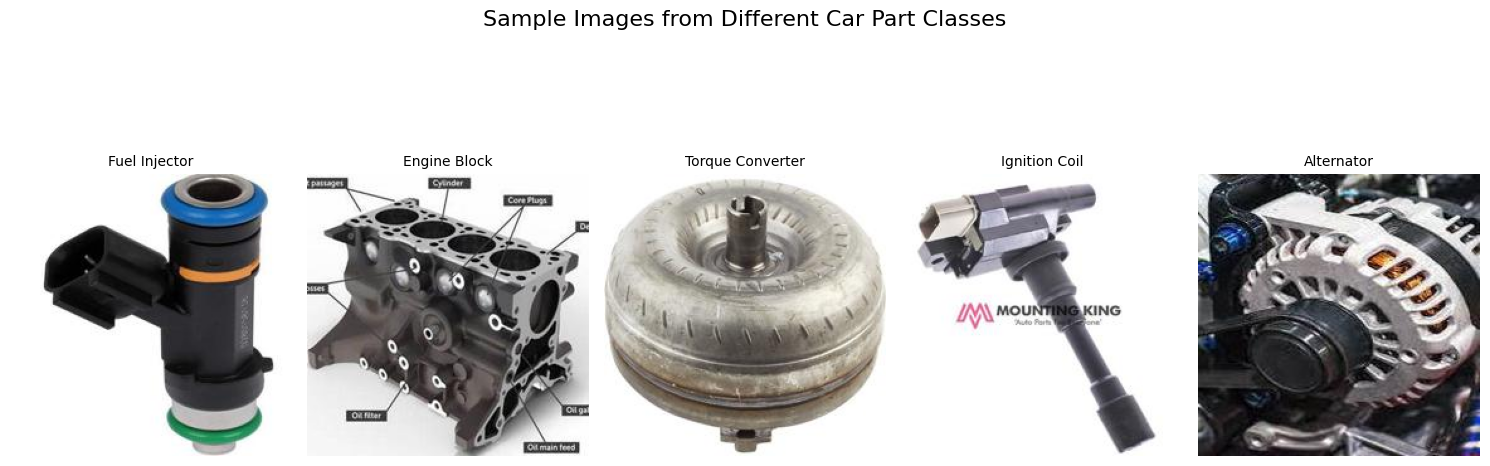

In [ ]:
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image
from PIL import Image

dataset_path = './dataset/train'

class_dirs = [d for d in os.listdir(dataset_path)
              if os.path.isdir(os.path.join(dataset_path, d)) and not d.startswith('.')]

sampled_classes = random.sample(class_dirs, min(5, len(class_dirs)))

plt.figure(figsize=(15, 6))

for i, class_name in enumerate(sampled_classes):
    class_folder = os.path.join(dataset_path, class_name)

    valid_extensions = ['.jpg', '.jpeg', '.png']
    images_in_class = [f for f in os.listdir(class_folder)
                       if f.lower().endswith(tuple(valid_extensions)) and not f.startswith('.')]

    if not images_in_class:
        continue

    sample_image = random.choice(images_in_class)
    img_path = os.path.join(class_folder, sample_image)

    img = image.load_img(img_path, target_size=(224, 224))
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(class_name.title(), fontsize=10)
    plt.axis("off")

plt.suptitle("Sample Images from Different Car Part Classes", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/car parts.csv')
df.head(20)

,class index,filepaths,labels,data set
0,0,train/AIR COMPRESSOR/001.jpg,AIR COMPRESSOR,train
1,0,train/AIR COMPRESSOR/002.jpg,AIR COMPRESSOR,train
2,0,train/AIR COMPRESSOR/003.jpg,AIR COMPRESSOR,train
3,0,train/AIR COMPRESSOR/004.jpg,AIR COMPRESSOR,train
4,0,train/AIR COMPRESSOR/005.jpg,AIR COMPRESSOR,train
5,0,train/AIR COMPRESSOR/006.jpg,AIR COMPRESSOR,train
6,0,train/AIR COMPRESSOR/007.jpg,AIR COMPRESSOR,train
7,0,train/AIR COMPRESSOR/008.jpg,AIR COMPRESSOR,train
8,0,train/AIR COMPRESSOR/009.jpg,AIR COMPRESSOR,train
9,0,train/AIR COMPRESSOR/010.jpg,AIR COMPRESSOR,train


In [ ]:
label_counts = df['labels'].value_counts().sort_values(ascending=False)
label_counts

,count
labels,
IGNITION COIL,210
IDLER ARM,208
STARTER,205
CARBERATOR,202
ALTERNATOR,200
OVERFLOW TANK,199
SHIFT KNOB,199
RADIO,199
FUEL INJECTOR,198


#### TODO: Research about data augmentation and what to do in case of an unbalanced dataset
##### At the end of the notebook, you can apply these techniques and train another CNN and compare results

### Your task:

#### Quick CNN Workflow for Image Classification

1. **Load & preprocess data**  
   - Resize images and normalize pixel values (e.g., scale pixels to [0,1])  
   - Prepare labels for classification  

2. **Create training and validation data generators**  
   - Use `ImageDataGenerator` or custom loaders to batch and augment data  (If you want to, or skip this part for now)

3. **Build the CNN model**  
   - Stack convolutional layers (Conv2D + activation function) and pooling layers
   - Flatten and add dense layers for final classification  
   - Make sure to use the right activation function for the last Dense layer.

4. **Compile the model**  
   - Use suitable loss function nd an optimizer like Adam  

5. **Train the model**  
   - Fit the model on training data and validate on validation data over multiple epochs  
   - Find the right number of batches/epochs for your data

6. **Evaluate and visualize results**  
   - Plot Accuracy & Loss Curves for training/validation
   - Learn about overfitting/underfitting and how to prevent these situations
   - Generate confusion matrix and classification report, based on metrics like accuracy

7. **Explore**
   - Use a pretrained available model
   - Change the architecture
   - Integrate the model into a small GUI and make it more interactive
   - Test with images from the internet, and see how well it performs


# Configurations

In [ ]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

# reproducibility
SEED = 42
random.seed(SEED)
tf.random.set_seed(SEED)

# dataset paths
DATASET_DIR = Path("./dataset")
CSV_PATH = DATASET_DIR / "car parts.csv"

TRAIN_DIR = DATASET_DIR / "train"
VALID_DIR = DATASET_DIR / "valid"
TEST_DIR = DATASET_DIR / "test"

# image pipeline configuration
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
split_directories = {
    "train": TRAIN_DIR,
    "valid": VALID_DIR,
    "test": TEST_DIR
}

for split_name, split_path in split_directories.items():
    if not split_path.exists():
        raise FileNotFoundError(
            f"The '{split_name}' directory was not found: {split_path}"
        )

    print(f"{split_name}: {split_path}")

train: dataset/train
valid: dataset/valid
test: dataset/test


In [ ]:
print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (9239, 4)

Columns:
['class index', 'filepaths', 'labels', 'data set']


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
class index    0
filepaths      0
labels         0
data set       0
dtype: int64


In [ ]:
number_of_classes = df["labels"].nunique()

print(f"Number of classes: {number_of_classes}")

Number of classes: 50


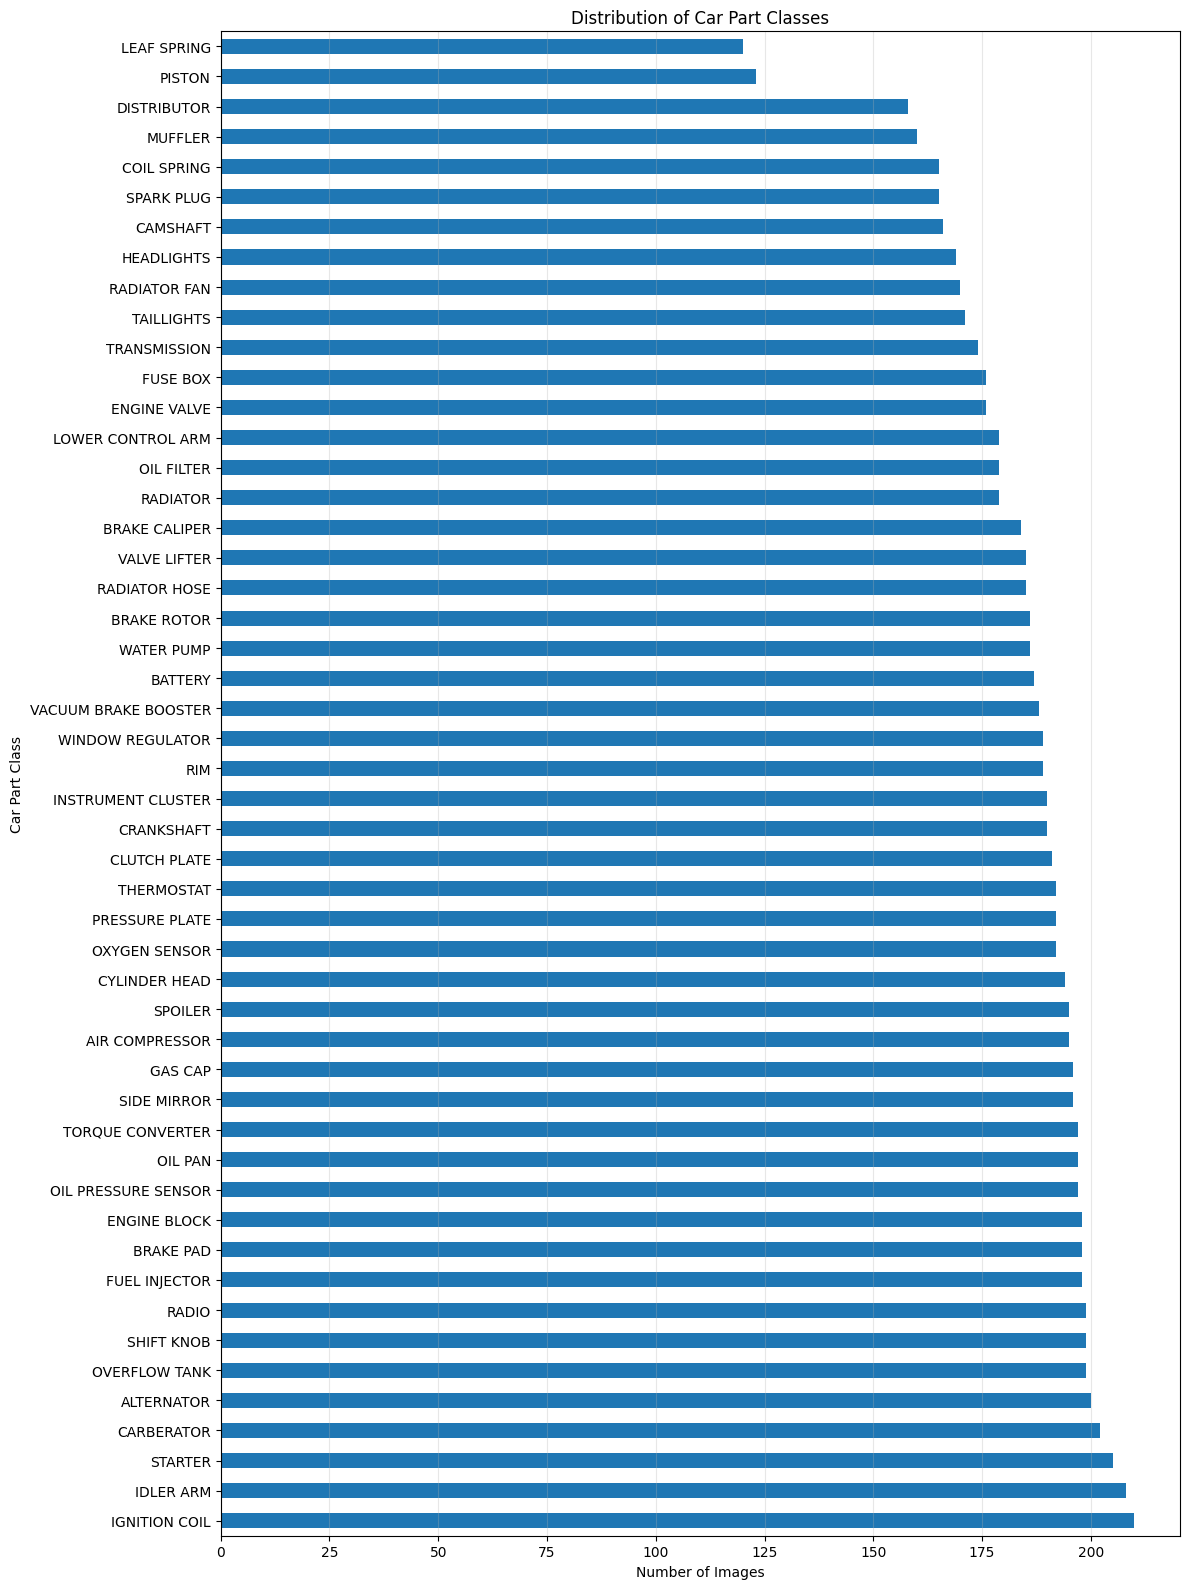

In [ ]:
plt.figure(figsize=(12, 16))

label_counts.plot(kind="barh")

plt.title("Distribution of Car Part Classes")
plt.xlabel("Number of Images")
plt.ylabel("Car Part Class")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Class Distribution Observation

The dataset contains 50 car part classes. The number of images is not
identical for all classes, which indicates a degree of class imbalance.
However, the image loading pipeline will initially use all available
images without resampling.

# Pipeline for train, test, validation

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 8739 files belonging to 50 classes.


In [ ]:
class_names = train_dataset.class_names

print(f"Number of classes: {len(class_names)}")
print("\nClass names:")
print(class_names)

assert len(class_names) == 50, (
    f"Expected 50 classes, but found {len(class_names)}."
)

Number of classes: 50

Class names:
['AIR COMPRESSOR', 'ALTERNATOR', 'BATTERY', 'BRAKE CALIPER', 'BRAKE PAD', 'BRAKE ROTOR', 'CAMSHAFT', 'CARBERATOR', 'CLUTCH PLATE', 'COIL SPRING', 'CRANKSHAFT', 'CYLINDER HEAD', 'DISTRIBUTOR', 'ENGINE BLOCK', 'ENGINE VALVE', 'FUEL INJECTOR', 'FUSE BOX', 'GAS CAP', 'HEADLIGHTS', 'IDLER ARM', 'IGNITION COIL', 'INSTRUMENT CLUSTER', 'LEAF SPRING', 'LOWER CONTROL ARM', 'MUFFLER', 'OIL FILTER', 'OIL PAN', 'OIL PRESSURE SENSOR', 'OVERFLOW TANK', 'OXYGEN SENSOR', 'PISTON', 'PRESSURE PLATE', 'RADIATOR', 'RADIATOR FAN', 'RADIATOR HOSE', 'RADIO', 'RIM', 'SHIFT KNOB', 'SIDE MIRROR', 'SPARK PLUG', 'SPOILER', 'STARTER', 'TAILLIGHTS', 'THERMOSTAT', 'TORQUE CONVERTER', 'TRANSMISSION', 'VACUUM BRAKE BOOSTER', 'VALVE LIFTER', 'WATER PUMP', 'WINDOW REGULATOR']


In [ ]:
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 250 files belonging to 50 classes.


In [ ]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 250 files belonging to 50 classes.


In [ ]:
def normalize_images(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .map(
        normalize_images,
        num_parallel_calls=AUTOTUNE
    )
    .prefetch(AUTOTUNE)
)

valid_dataset = (
    valid_dataset
    .map(
        normalize_images,
        num_parallel_calls=AUTOTUNE
    )
    .prefetch(AUTOTUNE)
)

test_dataset = (
    test_dataset
    .map(
        normalize_images,
        num_parallel_calls=AUTOTUNE
    )
    .prefetch(AUTOTUNE)
)

In [ ]:
datasets = {
    "Train": train_dataset,
    "Validation": valid_dataset,
    "Test": test_dataset
}

for split_name, dataset in datasets.items():
    image_batch, label_batch = next(iter(dataset))

    minimum_pixel_value = tf.reduce_min(image_batch).numpy()
    maximum_pixel_value = tf.reduce_max(image_batch).numpy()

    print(f"\n{split_name} dataset")
    print(f"Image batch shape: {image_batch.shape}")
    print(f"Label batch shape: {label_batch.shape}")
    print(f"Minimum pixel value: {minimum_pixel_value:.4f}")
    print(f"Maximum pixel value: {maximum_pixel_value:.4f}")

    assert minimum_pixel_value >= 0.0
    assert maximum_pixel_value <= 1.0


Train dataset
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0000
Maximum pixel value: 1.0000

Validation dataset
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0000
Maximum pixel value: 1.0000

Test dataset
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0000
Maximum pixel value: 1.0000


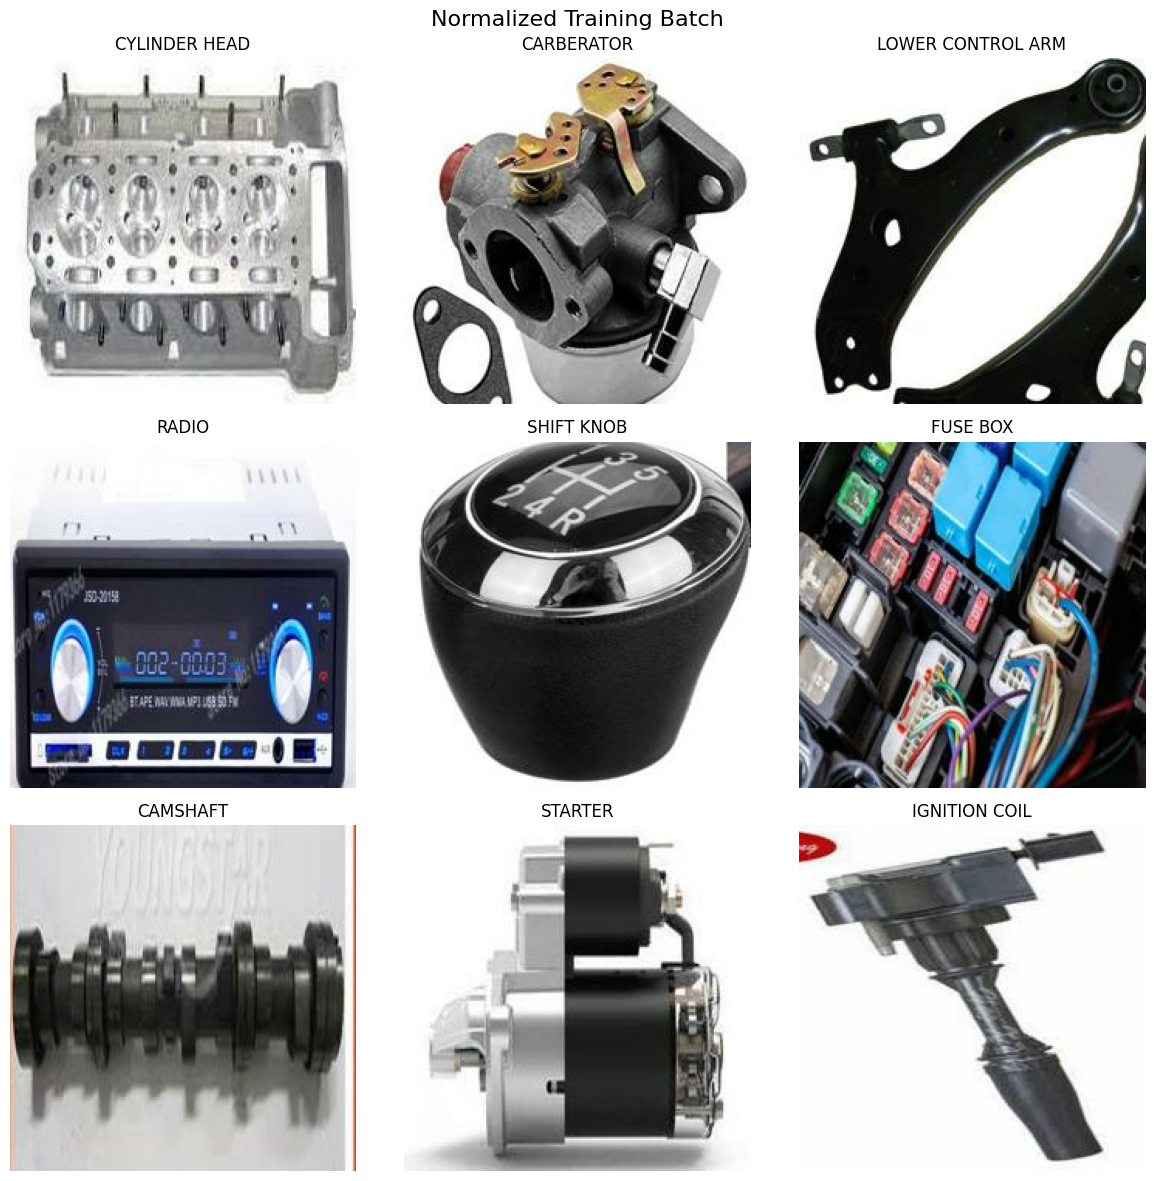

In [ ]:
image_batch, label_batch = next(iter(train_dataset))

plt.figure(figsize=(12, 12))

for index in range(9):
    axis = plt.subplot(3, 3, index + 1)

    plt.imshow(image_batch[index].numpy())
    plt.title(
        class_names[int(label_batch[index].numpy())]
    )
    plt.axis("off")

plt.suptitle(
    "Normalized Training Batch",
    fontsize=16
)
plt.tight_layout()
plt.show()

## Conclusion

The image dataset was successfully explored and prepared for deep learning.
The metadata confirmed the presence of 50 car part classes, while the class
distribution plot and sample image grid provided an overview of the dataset
structure and image variety.

Separate data pipelines were created for the training, validation, and test
sets. The images were resized to 224x224 pixels, converted to RGB batches, and
normalized to the [0, 1] range. The batch inspection confirmed that the pipeline
returns images with the expected shape and one integer class label for each
image.

The dataset is now ready to be used for building and training a CNN
classification model.

# CNN Model Architecture

This section defines a Convolutional Neural Network for classifying car part
images into 50 classes.

The model contains four convolutional blocks. Each block uses a convolutional
layer with ReLU activation followed by max pooling. The convolutional layers
extract progressively more complex visual features, while the pooling layers
reduce the spatial dimensions of the feature maps.

The extracted features are flattened and passed to a fully connected hidden
layer. The final Softmax layer produces one probability for each car part class.

In [ ]:
INPUT_SHAPE = (*IMAGE_SIZE, 3)
NUM_CLASSES = len(class_names)

assert IMAGE_SIZE == (224, 224), (
    f"Expected image size (224, 224), but found {IMAGE_SIZE}."
)

assert NUM_CLASSES == 50, (
    f"Expected 50 classes, but found {NUM_CLASSES}."
)

print(f"Model input shape: {INPUT_SHAPE}")
print(f"Number of output classes: {NUM_CLASSES}")

Model input shape: (224, 224, 3)
Number of output classes: 50


In [ ]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=INPUT_SHAPE,
            name="input_image"
        ),

        # convolutional block 1
        tf.keras.layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            name="conv_block_1"
        ),
        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            name="pool_block_1"
        ),

        # convolutional block 2
        tf.keras.layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            name="conv_block_2"
        ),
        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            name="pool_block_2"
        ),

        # convolutional block 3
        tf.keras.layers.Conv2D(
            filters=128,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            name="conv_block_3"
        ),
        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            name="pool_block_3"
        ),

        # convolutional block 4
        tf.keras.layers.Conv2D(
            filters=128,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            name="conv_block_4"
        ),
        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            name="pool_block_4"
        ),

        # classification layers
        tf.keras.layers.Flatten(
            name="flatten_features"
        ),
        tf.keras.layers.Dense(
            units=128,
            activation="relu",
            name="dense_hidden"
        ),
        tf.keras.layers.Dense(
            units=NUM_CLASSES,
            activation="softmax",
            name="class_probabilities"
        )
    ],
    name="car_parts_cnn"
)

In [ ]:
model.summary()

Model: "car_parts_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_block_1 (Conv2D)           │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block_1 (MaxPooling2D)     │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_2 (Conv2D)           │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block_2 (MaxPooling2D)     │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_3 (Conv2D)           │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block_3 (MaxPooling2D)     │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_4 (Conv2D)           │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block_4 (MaxPooling2D)     │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_features (Flatten)      │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,458,674 (13.19 MB)

 Trainable params: 3,458,674 (13.19 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
convolutional_layers = [
    layer
    for layer in model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

pooling_layers = [
    layer
    for layer in model.layers
    if isinstance(layer, tf.keras.layers.MaxPooling2D)
]

output_layer = model.layers[-1]

print(f"Convolutional layers: {len(convolutional_layers)}")
print(f"Pooling layers: {len(pooling_layers)}")
print(f"Model input shape: {model.input_shape}")
print(f"Model output shape: {model.output_shape}")
print(f"Output neurons: {output_layer.units}")
print(f"Output activation: {output_layer.activation.__name__}")

assert len(convolutional_layers) >= 3
assert len(pooling_layers) >= 3
assert model.input_shape == (None, 224, 224, 3)
assert model.output_shape == (None, 50)
assert output_layer.units == 50
assert output_layer.activation.__name__ == "softmax"

print("\nAll architecture requirements were successfully verified.")

Convolutional layers: 4
Pooling layers: 4
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 50)
Output neurons: 50
Output activation: softmax

All architecture requirements were successfully verified.


### Architecture Analysis

The model receives RGB images with a shape of 224×224×3 and processes them
through four convolutional blocks. Each max-pooling layer reduces the spatial
dimensions by half, while the number of filters increases from 32 to 128 to
capture progressively more complex visual features.

After the final pooling operation, the feature maps have a shape of
14×14×128. The `Flatten` layer converts them into a vector of 25,088 values,
which is passed to a hidden layer with 128 neurons.

Most of the model parameters are located in the hidden Dense layer because
each flattened feature is connected to every Dense neuron. The fourth
convolutional block reduces the feature-map dimensions before flattening,
significantly limiting the number of Dense parameters.

The final layer contains 50 neurons with Softmax activation, producing one
class probability for each car part category.

In [ ]:
convolutional_layers = [
    layer
    for layer in model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

pooling_layers = [
    layer
    for layer in model.layers
    if isinstance(layer, tf.keras.layers.MaxPooling2D)
]

dense_layers = [
    layer
    for layer in model.layers
    if isinstance(layer, tf.keras.layers.Dense)
]

output_layer = model.layers[-1]

print(f"Convolutional layers: {len(convolutional_layers)}")
print(f"Pooling layers: {len(pooling_layers)}")
print(f"Dense layers: {len(dense_layers)}")
print(f"Model input shape: {model.input_shape}")
print(f"Model output shape: {model.output_shape}")
print(f"Output neurons: {output_layer.units}")
print(f"Output activation: {output_layer.activation.__name__}")

assert len(convolutional_layers) >= 3, (
    "The model must contain at least three convolutional layers."
)

assert len(pooling_layers) >= 3, (
    "The model must contain at least three pooling layers."
)

assert len(dense_layers) >= 2, (
    "The model must contain at least one hidden Dense layer "
    "and one output Dense layer."
)

assert model.input_shape == (None, 224, 224, 3), (
    f"Unexpected input shape: {model.input_shape}"
)

assert model.output_shape == (None, 50), (
    f"Unexpected output shape: {model.output_shape}"
)

assert output_layer.units == 50, (
    f"Expected 50 output neurons, but found {output_layer.units}."
)

assert output_layer.activation.__name__ == "softmax", (
    "The output layer must use Softmax activation."
)

print("\nAll CNN architecture requirements were successfully verified.")

Convolutional layers: 4
Pooling layers: 4
Dense layers: 2
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 50)
Output neurons: 50
Output activation: softmax

All CNN architecture requirements were successfully verified.


## CNN Architecture Conclusion

A custom CNN architecture was defined for the classification of 50 car part
categories. The model accepts RGB images with a resolution of 224×224 pixels
and contains four convolutional blocks.

Each block combines a `Conv2D` layer with ReLU activation and a
`MaxPooling2D` layer. The number of filters increases from 32 to 128 as the
spatial dimensions decrease, allowing the model to represent progressively
more complex visual features.

After the final convolutional block, the feature maps are flattened and passed
to a hidden Dense layer with 128 neurons. The output layer contains 50 neurons
with Softmax activation, producing one class probability for each car part
category.

The model contains 3,458,674 trainable parameters. Most of these parameters
belong to the hidden Dense layer because every flattened feature is connected
to every neuron in that layer.

# Model Training

The CNN is compiled using the Adam optimizer and sparse categorical
cross-entropy loss.

Sparse categorical cross-entropy is used because the dataset labels are
represented as integer class indices from 0 to 49. Accuracy is monitored
during training and validation to measure the percentage of correctly
classified images.

In [ ]:
LEARNING_RATE = 0.001
EPOCHS = 15

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")
print(f"Optimizer: {model.optimizer.__class__.__name__}")
print(f"Learning rate: {float(model.optimizer.learning_rate.numpy())}")
print(f"Loss function: {model.loss}")
print(f"Metrics: accuracy")
print(f"Planned epochs: {EPOCHS}")

Model compiled successfully.
Optimizer: Adam
Learning rate: 0.0010000000474974513
Loss function: sparse_categorical_crossentropy
Metrics: accuracy
Planned epochs: 15


## CNN Training

The CNN will be trained on the training dataset for 15 epochs using batches
of 32 images. After each epoch, the model will be evaluated on the validation
dataset.

The validation dataset is used only to monitor generalization performance.
Its images do not contribute to the weight updates performed by the Adam
optimizer.

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - accuracy: 0.1840 - loss: 3.2267 - val_accuracy: 0.3360 - val_loss: 2.4998
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.4936 - loss: 1.9025 - val_accuracy: 0.4840 - val_loss: 2.0631
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.6910 - loss: 1.1185 - val_accuracy: 0.4720 - val_loss: 2.2255
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.8329 - loss: 0.5708 - val_accuracy: 0.5200 - val_loss: 2.7669
Epoch 5/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.9004 - loss: 0.3434 - val_accuracy: 0.4960 - val_loss: 3.3828
Epoch 6/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.9439 - loss: 0.1802 - val_accuracy: 0.5080 - val_loss: 3.5703
Epoch 7/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.9513 - loss: 0.1602 - val_accuracy: 0.5400 - val_loss: 3.6554
Epoch 8/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.9689 - loss: 0.0934 - 

In [ ]:
history_df = pd.DataFrame(history.history)

history_df.index = range(1, len(history_df) + 1)
history_df.index.name = "Epoch"

required_metrics = {
    "loss",
    "accuracy",
    "val_loss",
    "val_accuracy"
}

missing_metrics = required_metrics.difference(
    history_df.columns
)

assert not missing_metrics, (
    f"Missing training metrics: {missing_metrics}"
)

assert len(history_df) == EPOCHS, (
    f"Expected {EPOCHS} completed epochs, "
    f"but found {len(history_df)}."
)

print(f"Completed epochs: {len(history_df)}")
display(history_df.round(4))

Completed epochs: 15


,accuracy,loss,val_accuracy,val_loss
Epoch,,,,
1,0.1840,3.2267,0.336,2.4998
2,0.4936,1.9025,0.484,2.0631
3,0.6910,1.1185,0.472,2.2255
4,0.8329,0.5708,0.520,2.7669
5,0.9004,0.3434,0.496,3.3828
6,0.9439,0.1802,0.508,3.5703
7,0.9513,0.1602,0.540,3.6554
8,0.9689,0.0934,0.528,4.0297
9,0.9769,0.0726,0.480,4.7023


## Training Curves

The training history is used to visualize how the model's loss and accuracy
change across epochs.

Training and validation metrics are plotted together to evaluate whether the
model learns useful patterns and generalizes to unseen validation images.

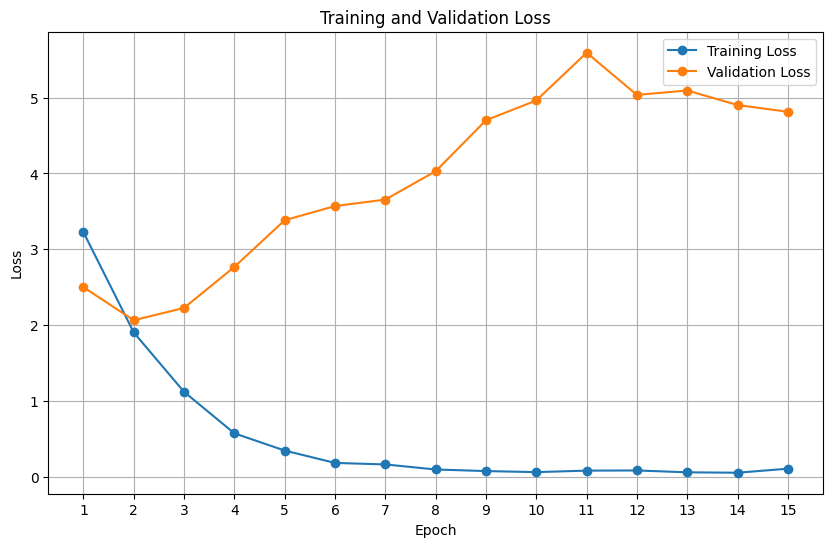

In [ ]:
training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

epochs_range = range(1, len(training_loss) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    training_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    validation_loss,
    marker="o",
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)
plt.show()

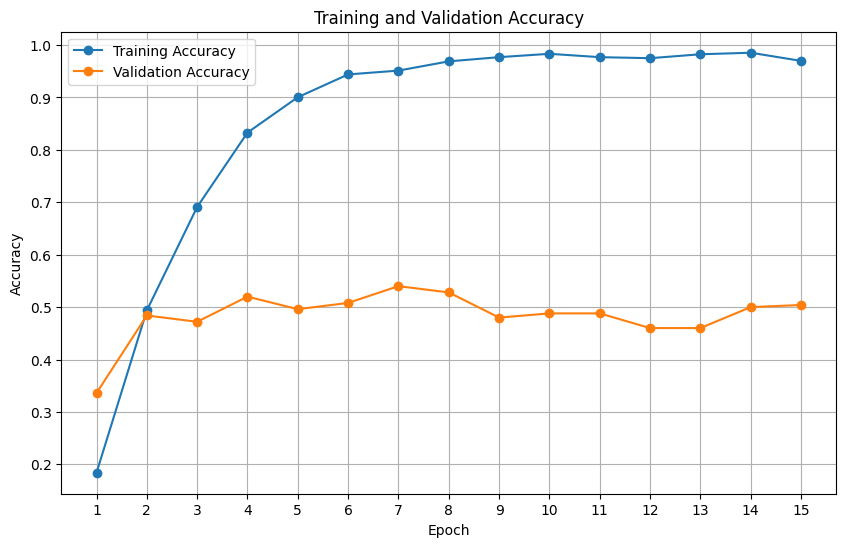

In [ ]:
training_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    training_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    validation_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

best_loss_epoch = np.argmin(validation_loss) + 1
best_accuracy_epoch = np.argmax(validation_accuracy) + 1

best_validation_loss = validation_loss[best_loss_epoch - 1]
best_validation_accuracy = validation_accuracy[
    best_accuracy_epoch - 1
]

print(
    f"Best validation loss: "
    f"{best_validation_loss:.4f} "
    f"at epoch {best_loss_epoch}"
)

print(
    f"Best validation accuracy: "
    f"{best_validation_accuracy:.4f} "
    f"at epoch {best_accuracy_epoch}"
)

Best validation loss: 2.0631 at epoch 2
Best validation accuracy: 0.5400 at epoch 7


## Training Analysis and Conclusion

The CNN shows clear signs of overfitting. During the first three epochs, both the training and validation performance improve. The lowest validation loss, approximately 2.18, is reached at epoch 3, which suggests that this is the best validation point when validation loss is used as the main criterion.

After epoch 3, the training loss continues to decrease and reaches approximately 0.06 at epoch 15, while the training accuracy increases to about 98.24%. However, the validation loss starts to increase, and the validation accuracy remains around 48%–52%. The highest validation accuracy is 52% and is reached at epoch 10, but the validation loss at that point is already considerably higher than at epoch 3.

The large difference between the final training accuracy and validation accuracy indicates that the model learns the training images very well but does not generalize equally well to unseen images. Therefore, the model becomes increasingly confident on the training data without achieving a similar improvement on the validation set.

Based on the validation loss, epoch 3 can be considered the best epoch. Future experiments could reduce overfitting by using data augmentation, dropout, early stopping, batch normalization, or L2 regularization. Replacing the `Flatten` layer with `GlobalAveragePooling2D` could also reduce the number of parameters and improve generalization.

# Test Set Evaluation

The trained CNN is evaluated exclusively on the test set. This section reports
the overall test accuracy, per-class precision, recall and F1-score, and analyzes
the most frequent classification errors using a confusion matrix.

In [ ]:
import numpy as np
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
test_probabilities = model.predict(
    test_dataset,
    verbose=1
)

y_pred = np.argmax(
    test_probabilities,
    axis=1
)

y_true = np.concatenate(
    [
        label_batch.numpy()
        for _, label_batch in test_dataset
    ],
    axis=0
).astype(int)

print(f"Prediction probabilities shape: {test_probabilities.shape}")
print(f"Predicted labels shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")

assert test_probabilities.shape == (
    len(y_true),
    NUM_CLASSES
), (
    "The prediction matrix does not have the expected shape."
)

assert len(y_pred) == len(y_true), (
    "The number of predictions does not match "
    "the number of true labels."
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
Prediction probabilities shape: (250, 50)
Predicted labels shape: (250,)
True labels shape: (250,)


In [ ]:
test_accuracy = accuracy_score(
    y_true,
    y_pred
)

print(f"Overall test accuracy: {test_accuracy:.4f}")
print(f"Overall test accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:\n")

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

Overall test accuracy: 0.5320
Overall test accuracy: 53.20%

Classification Report:

                      precision    recall  f1-score   support

      AIR COMPRESSOR     0.7500    0.6000    0.6667         5
          ALTERNATOR     0.4444    0.8000    0.5714         5
             BATTERY     1.0000    0.8000    0.8889         5
       BRAKE CALIPER     0.4000    0.4000    0.4000         5
           BRAKE PAD     0.6000    0.6000    0.6000         5
         BRAKE ROTOR     0.3333    0.2000    0.2500         5
            CAMSHAFT     0.7500    0.6000    0.6667         5
          CARBERATOR     0.5000    0.8000    0.6154         5
        CLUTCH PLATE     0.7500    0.6000    0.6667         5
         COIL SPRING     1.0000    0.8000    0.8889         5
          CRANKSHAFT     0.7500    0.6000    0.6667         5
       CYLINDER HEAD     0.1250    0.2000    0.1538         5
         DISTRIBUTOR     0.3000    0.6000    0.4000         5
        ENGINE BLOCK     0.5000    0.4000    0

Confusion matrix shape: (50, 50)


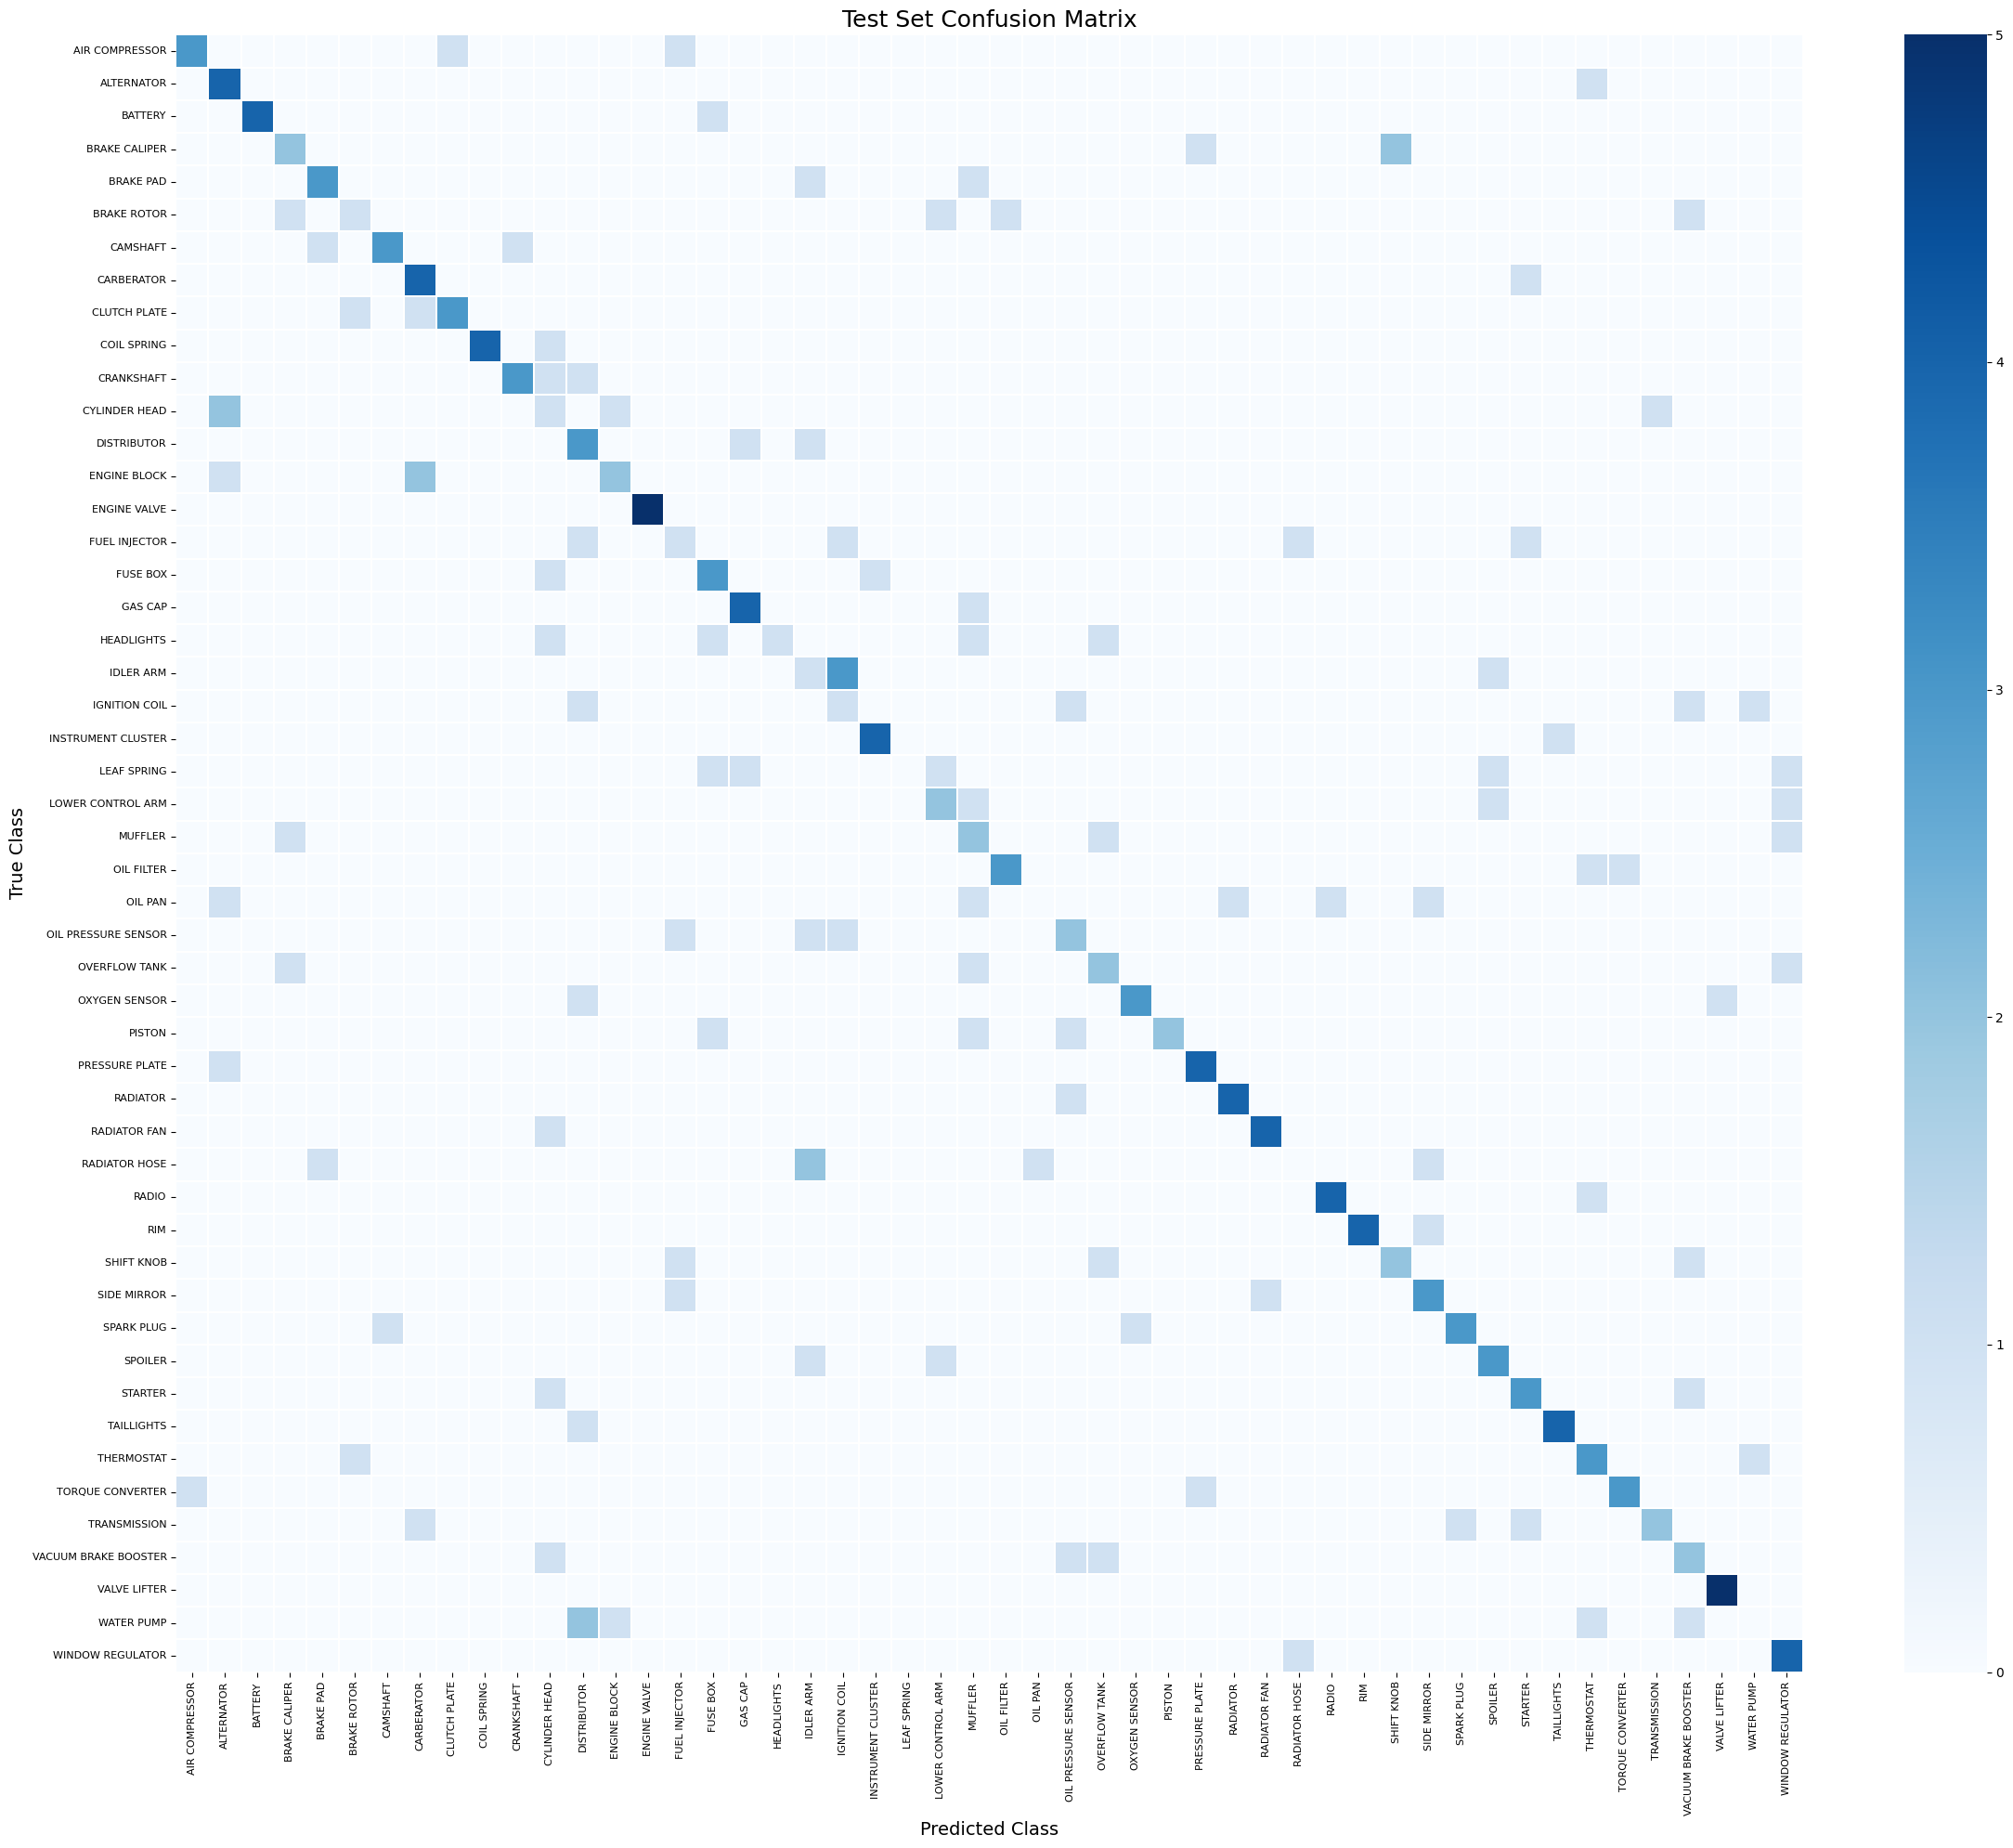

In [ ]:
test_confusion_matrix = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

print(
    "Confusion matrix shape:",
    test_confusion_matrix.shape
)

assert test_confusion_matrix.shape == (
    NUM_CLASSES,
    NUM_CLASSES
), (
    "The confusion matrix does not have "
    "the expected shape."
)

plt.figure(figsize=(24, 20))

sns.heatmap(
    test_confusion_matrix,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot=False,
    cbar=True,
    linewidths=0.1
)

plt.title(
    "Test Set Confusion Matrix",
    fontsize=18
)

plt.xlabel(
    "Predicted Class",
    fontsize=14
)

plt.ylabel(
    "True Class",
    fontsize=14
)

plt.xticks(
    rotation=90,
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)

plt.tight_layout()
plt.show()

In [ ]:
confused_pairs = []

for first_class_index in range(NUM_CLASSES):
    for second_class_index in range(
        first_class_index + 1,
        NUM_CLASSES
    ):
        first_as_second = test_confusion_matrix[
            first_class_index,
            second_class_index
        ]

        second_as_first = test_confusion_matrix[
            second_class_index,
            first_class_index
        ]

        total_confusions = (
            first_as_second + second_as_first
        )

        if total_confusions > 0:
            confused_pairs.append(
                {
                    "Class A": class_names[
                        first_class_index
                    ],
                    "Class B": class_names[
                        second_class_index
                    ],
                    "A predicted as B": int(
                        first_as_second
                    ),
                    "B predicted as A": int(
                        second_as_first
                    ),
                    "Total confusions": int(
                        total_confusions
                    )
                }
            )

confused_pairs_df = pd.DataFrame(
    confused_pairs
).sort_values(
    by="Total confusions",
    ascending=False
).reset_index(drop=True)

top_3_confused_pairs = confused_pairs_df.head(3)

print("Top 3 most confused class pairs:")
display(top_3_confused_pairs)

assert len(top_3_confused_pairs) == 3, (
    "Expected three confused class pairs."
)

Top 3 most confused class pairs:


,Class A,Class B,A predicted as B,B predicted as A,Total confusions
0,IDLER ARM,IGNITION COIL,3,0,3
1,CARBERATOR,ENGINE BLOCK,0,2,2
2,BRAKE CALIPER,SHIFT KNOB,2,0,2


In [ ]:
test_images = np.concatenate(
    [
        image_batch.numpy()
        for image_batch, _ in test_dataset
    ],
    axis=0
)

print(f"Collected test images shape: {test_images.shape}")

assert len(test_images) == len(y_true), (
    "The number of collected test images does not match "
    "the number of true labels."
)

Collected test images shape: (250, 224, 224, 3)


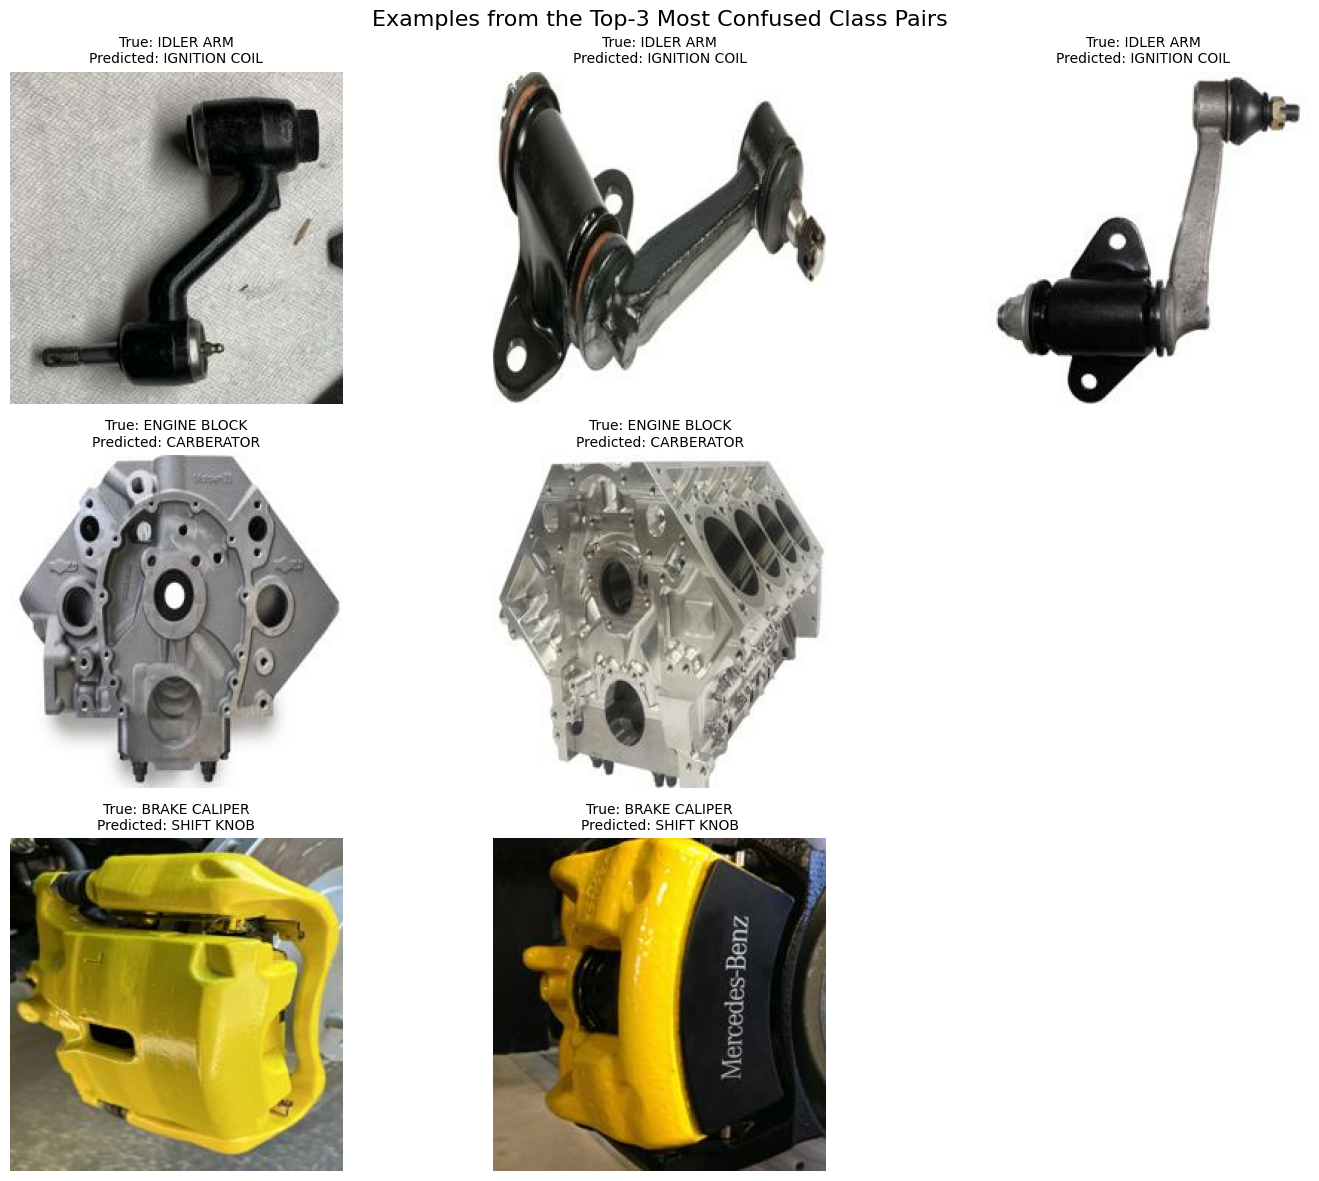

In [ ]:
MAX_EXAMPLES_PER_PAIR = 3

figure, axes = plt.subplots(
    nrows=3,
    ncols=MAX_EXAMPLES_PER_PAIR,
    figsize=(15, 12)
)

for row_index, (_, pair) in enumerate(
    top_3_confused_pairs.iterrows()
):
    class_a_name = pair["Class A"]
    class_b_name = pair["Class B"]

    class_a_index = class_names.index(class_a_name)
    class_b_index = class_names.index(class_b_name)

    confused_image_indices = np.where(
        (
            (y_true == class_a_index)
            & (y_pred == class_b_index)
        )
        |
        (
            (y_true == class_b_index)
            & (y_pred == class_a_index)
        )
    )[0]

    for column_index in range(
        MAX_EXAMPLES_PER_PAIR
    ):
        axis = axes[row_index, column_index]

        if column_index < len(confused_image_indices):
            image_index = confused_image_indices[
                column_index
            ]

            true_class_name = class_names[
                y_true[image_index]
            ]

            predicted_class_name = class_names[
                y_pred[image_index]
            ]

            axis.imshow(test_images[image_index])

            axis.set_title(
                f"True: {true_class_name}\n"
                f"Predicted: {predicted_class_name}",
                fontsize=10
            )
        else:
            axis.set_visible(False)

        axis.axis("off")

    axes[row_index, 0].set_ylabel(
        f"{class_a_name}\nvs\n{class_b_name}",
        fontsize=11
    )

plt.suptitle(
    "Examples from the Top-3 Most Confused Class Pairs",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Test Evaluation and Confusion Analysis

The CNN achieved an overall test accuracy of **48.00%**, correctly classifying
120 out of 250 test images. The macro-average F1-score and weighted-average
F1-score are both approximately **0.4788**. These two values are equal because
the test set is balanced, with exactly five images for each of the 50 classes.

The per-class results vary considerably. The model achieved perfect precision,
recall, and F1-score for `ENGINE VALVE`. It also performed well for classes such
as `BATTERY`, `INSTRUMENT CLUSTER`, `RADIATOR`, and `TAILLIGHTS`. However, the
model failed to correctly classify any test images from `IGNITION COIL`,
`LEAF SPRING`, and `OIL PAN`, resulting in an F1-score of zero for these
classes.

### Top-3 Most Confused Class Pairs

#### 1. IDLER ARM vs IGNITION COIL

Three `IDLER ARM` images were incorrectly predicted as `IGNITION COIL`.
In the displayed examples, the idler arms contain compact dark cylindrical
sections, narrow metal extensions, and small connector-like components. These
local visual features can resemble the cylindrical body and connector structure
that may appear in ignition coil images.

The images are also photographed from different angles and mostly use plain
backgrounds. Therefore, the model may focus more strongly on the dark
cylindrical regions than on the complete geometry of the idler arm.

#### 2. CARBERATOR vs ENGINE BLOCK

Two `ENGINE BLOCK` images were incorrectly predicted as `CARBERATOR`.
Both classes can contain metallic gray components with complex cast surfaces,
multiple circular openings, holes, cavities, and mechanical details.

The engine block examples are tightly cropped and shown without clear scale
information. This makes it difficult for the CNN to understand that they are
large engine components. Instead, it may associate the visible metallic
textures and circular openings with similar patterns learned from carburetor
images.

#### 3. BRAKE CALIPER vs SHIFT KNOB

Two `BRAKE CALIPER` images were incorrectly predicted as `SHIFT KNOB`.
The confused brake calipers are brightly colored, glossy, compact, and
photographed in close-up views. Their rounded outer surfaces and isolated
presentation may resemble the smooth and compact appearance of some shift knob
images.

In this case, the confusion is probably influenced more by color, texture,
cropping, and general object silhouette than by the actual mechanical function
of the parts. This suggests that the model may rely too strongly on superficial
visual features instead of learning more discriminative structural details.

### Conclusion

The confusion matrix and classification report show that overall accuracy alone
does not fully describe the model's behavior. Although the CNN recognizes some
classes reliably, several visually complex or similarly presented parts remain
difficult to distinguish.

The earlier training curves showed strong overfitting, with approximately
98% training accuracy but only around 48% validation and test accuracy. The
test results confirm that the model learned the training images well but does
not generalize sufficiently to unseen examples.

Future improvements could include data augmentation, dropout, early stopping,
L2 regularization, batch normalization, and a less parameter-heavy architecture.
Using transfer learning with a pretrained CNN could also provide more robust
visual features. Additional and more diverse images would help the model learn
differences in shape rather than relying mainly on color, background, viewing
angle, or image crop.